# Practical Statistics for Data Scientists - Chapter 2
## Data and Sampling Distributions

This notebook covers concepts related to data sampling, bias, the Central Limit Theorem, bootstrap resampling, confidence intervals, normal quantile-quantile (QQ) plots, and common theoretical probability distributions.

### Environment Setup and Imports

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.utils import resample

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

### Mount Google Drive

To access files stored in your Google Drive, you need to mount it to your Colab environment. This will allow the notebook to read files from the specified path.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

## 1. Random Sampling and Sampling Bias

Demonstrating random sampling versus population parameters, and stratified sampling to prevent bias.

### Data Loading and Population Parameters

First, we load the `loans_income.csv` dataset. This dataset represents a population from which we will draw samples. We then calculate and display the mean and standard deviation of this entire population to establish population parameters.

In [12]:
loans_income = pd.read_csv('drive/MyDrive/Colab Notebooks/data/loans_income.csv', squeeze=True) if pd.__version__ < '1.4' else pd.read_csv('drive/MyDrive/Colab Notebooks/data/loans_income.csv').iloc[:, 0]

pop_mean = loans_income.mean()
pop_std = loans_income.std()
print(f"Population Mean Income: ${pop_mean:,.2f}")
print(f"Population Std Dev:     ${pop_std:,.2f}")

Population Mean Income: $68,760.52
Population Std Dev:     $32,872.04


### Simple Random Sampling

Here, we draw a simple random sample of size $n=1000$ from the `loans_income` population and calculate its mean. This demonstrates how a sample statistic (sample mean) can approximate a population parameter (population mean).

In [13]:
sample_1000 = loans_income.sample(n=1000, random_state=42)
print(f"Sample Mean (n=1000):   ${sample_1000.mean():,.2f}")

Sample Mean (n=1000):   $66,536.47


---

## 2. Sampling Distribution of a Statistic & Central Limit Theorem (CLT)

Illustrating how the distribution of sample means approaches normality as sample size $n$ increases, regardless of the underlying population distribution shape.

### Simulating Sampling Distributions

We simulate the sampling distribution of the mean for different sample sizes ($n=5, 20, 50$). For each sample size, we draw 1000 samples from the `loans_income` population and compute their means. The Central Limit Theorem states that as the sample size increases, the distribution of the sample means will approximate a normal distribution, regardless of the shape of the original population distribution.

In [14]:
results = []
for sample_size in [5, 20, 50]:
    sample_means = [
        loans_income.sample(n=sample_size).mean()
        for _ in range(1000)
    ]
    results.append(pd.DataFrame({
        'income': sample_means,
        'size': sample_size
    }))

results = pd.concat(results)

### Visualizing Sampling Distributions

The histograms below illustrate the sampling distributions for different sample sizes. Observe how the distribution becomes more bell-shaped (normal) as the sample size increases, demonstrating the Central Limit Theorem.

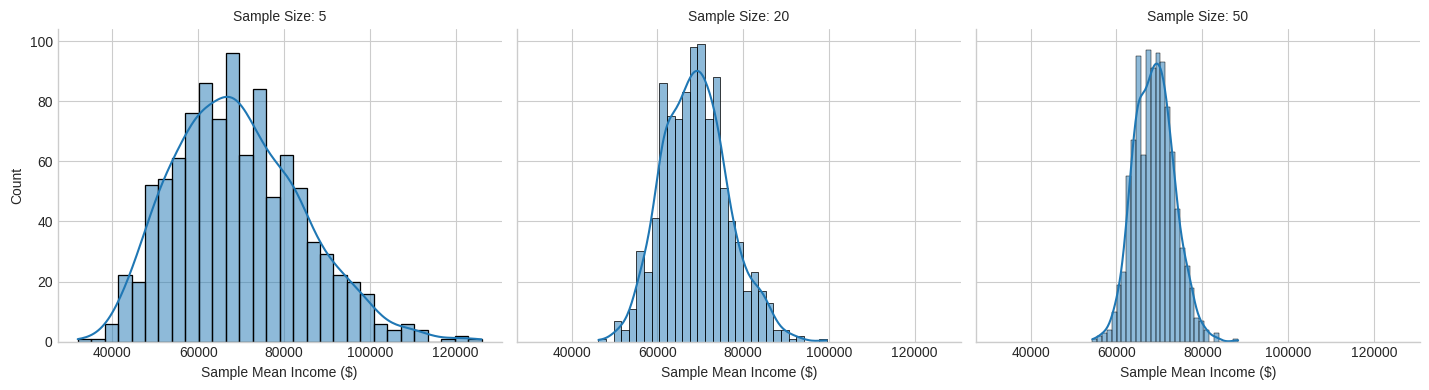

In [15]:
g = sns.FacetGrid(results, col='size', col_wrap=3, height=4, aspect=1.2)
g.map(sns.histplot, 'income', kde=True, bins=30)
g.set_axis_labels('Sample Mean Income ($)', 'Count')
g.set_titles(col_template='Sample Size: {col_name}')
plt.tight_layout()
plt.show()

### Empirical vs. Theoretical Standard Error

We compare the empirical standard error of the sampling distribution (for $n=50$) with the theoretical standard error, calculated as $\sigma / \sqrt{n}$, where $\sigma$ is the population standard deviation.

In [16]:
se_empirical = results[results['size'] == 50]['income'].std()
se_theoretical = pop_std / np.sqrt(50)
print(f"Empirical Standard Error (n=50):   ${se_empirical:,.2f}")
print(f"Theoretical Standard Error (n=50): ${se_theoretical:,.2f}")

Empirical Standard Error (n=50):   $4,592.80
Theoretical Standard Error (n=50): $4,648.81


---

## 3. Bootstrap Resampling & Confidence Intervals

Using bootstrap resampling to estimate uncertainty and construct non-parametric confidence intervals.

### Non-parametric Bootstrap for Median Income

Bootstrap resampling is a powerful technique for estimating the sampling distribution of a statistic by repeatedly re-sampling with replacement from the *observed* sample. Here, we apply bootstrap to estimate the median income.

In [17]:
bootstrap_medians = []
sample_data = loans_income.sample(n=500, random_state=42)

for _ in range(2000):
    boot_sample = resample(sample_data)
    bootstrap_medians.append(boot_sample.median())

bootstrap_medians = pd.Series(bootstrap_medians)

### Calculating a 95% Confidence Interval

From the bootstrap distribution of medians, we calculate the 95% confidence interval using percentiles.

In [18]:
ci_lower = bootstrap_medians.quantile(0.025)
ci_upper = bootstrap_medians.quantile(0.975)

print(f"Sample Median: ${sample_data.median():,.2f}")
print(f"95% Bootstrap Confidence Interval: [${ci_lower:,.2f}, ${ci_upper:,.2f}]")

Sample Median: $60,000.00
95% Bootstrap Confidence Interval: [$56,000.00, $62,672.30]


### Visualizing the Bootstrap Distribution

The histogram below shows the distribution of the bootstrap medians, with the 95% confidence interval highlighted.

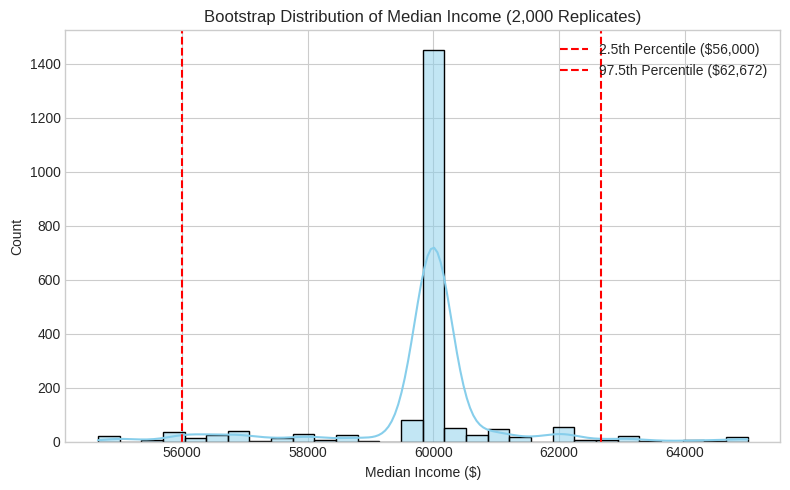

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(bootstrap_medians, kde=True, ax=ax, color='skyblue', bins=30)
ax.axvline(ci_lower, color='red', linestyle='--', label=f'2.5th Percentile (${ci_lower:,.0f})')
ax.axvline(ci_upper, color='red', linestyle='--', label=f'97.5th Percentile (${ci_upper:,.0f})')
ax.set_title('Bootstrap Distribution of Median Income (2,000 Replicates)')
ax.set_xlabel('Median Income ($)')
ax.legend()
plt.tight_layout()
plt.show()

---

## 4. Normal Distribution & QQ Plots

Assessing normality using standardized z-scores and Normal Quantile-Quantile (QQ) plots.

### Generating Data for QQ Plots

We generate a sample of standard normal data and compute Netflix stock returns to compare their distributions against a theoretical normal distribution using QQ plots.

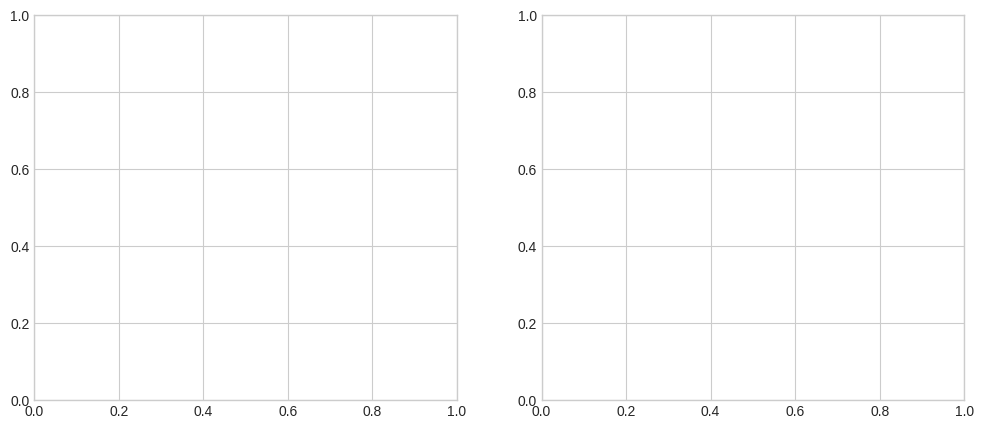

In [20]:
sp500_px = pd.read_csv('drive/MyDrive/Colab Notebooks/data/sp500_data.csv', index_col=0)
nflx_returns = np.diff(np.log(sp500_px['NFLX'][sp500_px['NFLX'] > 0]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

### Standard Normal QQ Plot

A Quantile-Quantile (QQ) plot is used to assess if a dataset follows a particular distribution, often a normal distribution. If the points lie approximately along a straight line, then the data follows that distribution. This plot shows a perfectly normal distribution.

In [21]:
stats.probplot(stats.norm.rvs(size=1000), dist="norm", plot=axes[0])
axes[0].set_title('QQ Plot: Normally Distributed Data')

Text(0.5, 1.0, 'QQ Plot: Normally Distributed Data')

### QQ Plot for Netflix Stock Returns (Heavy-tailed distribution)

This QQ plot for Netflix stock returns shows deviations from the straight line, particularly at the tails, indicating a "heavy-tailed" distribution (more extreme values than a normal distribution).

In [22]:
stats.probplot(nflx_returns, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot: Netflix Stock Returns (Fat Tails)')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

---

## 5. Discrete & Continuous Theoretical Distributions

Modeling probability scenarios using **Binomial**, **Poisson**, **Exponential**, and **Weibull** distributions.

### Binomial Distribution

The Binomial distribution models the probability of a certain number of successes in a fixed number of independent Bernoulli trials.
Here, we calculate the probability of 2 successes in 5 trials with a success probability $p=0.1$.

In [23]:
binom_prob = stats.binom.pmf(k=2, n=5, p=0.1)
print(f"Binomial PMF (k=2, n=5, p=0.1): {binom_prob:.4f}")

Binomial PMF (k=2, n=5, p=0.1): 0.0729


### Poisson Distribution

The Poisson distribution models the number of events occurring in a fixed interval of time or space, given a known average rate of occurrence.
We calculate the probability of exactly 4 events occurring, given an average rate $\lambda=2$ events per interval.

In [24]:
poisson_prob = stats.poisson.pmf(k=4, mu=2)
print(f"Poisson PMF (k=4, lambda=2):     {poisson_prob:.4f}")

Poisson PMF (k=4, lambda=2):     0.0902


### Exponential Distribution

The Exponential distribution describes the time between events in a Poisson process (events occurring continuously and independently at a constant average rate).
We generate 1000 samples from an exponential distribution with a mean arrival interval of 0.2 units.

In [25]:
exp_samples = stats.expon.rvs(scale=0.2, size=1000)

### Weibull Distribution

The Weibull distribution is a continuous probability distribution often used in reliability engineering and survival analysis to model failure rates that can change over time.
We generate 1000 samples from a Weibull distribution with shape parameter $c=1.5$ and scale parameter 5.

In [26]:
weibull_samples = stats.weibull_min.rvs(c=1.5, scale=5, size=1000)

### Visualizing Continuous Distributions

The histograms below show the shapes of the generated Exponential and Weibull distributions.

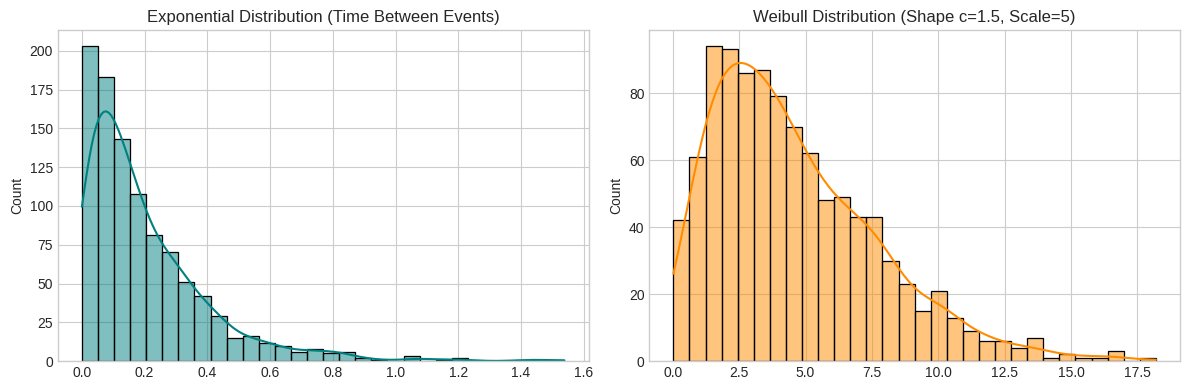

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(exp_samples, kde=True, ax=axes[0], color='teal', bins=30)
axes[0].set_title('Exponential Distribution (Time Between Events)')

sns.histplot(weibull_samples, kde=True, ax=axes[1], color='darkorange', bins=30)
axes[1].set_title('Weibull Distribution (Shape c=1.5, Scale=5)')

plt.tight_layout()
plt.show()